# Gdp

In [3]:
from src.utils.db import Db
import pandas as pd
import matplotlib as mpl
from typing import Union, cast
import numpy as np

db = Db("gdp")
# mpl.style.use("dark_background")
# mpl.rcParams = {
#     **mpl.rcParams,
#     "axes.facecolor": "#111",
#     "figure.facecolor": "#151515",
#     # "axes.facecolor": "#1a1a1a",
#     "axes.edgecolor": "gray",
#     "axes.labelcolor": "white",
#     "text.color": "white",
#     "xtick.color": "#666666",
#     "ytick.color": "#666666",
#     "grid.color": "gray",
#     # "figure.facecolor": "#1a1a1a",
#     "figure.edgecolor": "#1a1a1a",
#     # "savefig.facecolor": "#1a1a1a",
#     # "savefig.edgecolor": "#1a1a1a",
# }

### Symbolic select all

It also retrieves the columns

In [4]:
cols = [c.title() for c in db.select("columns.json", ["gdp"])[0][0].values()]
df = pd.DataFrame(db.select("all"), columns=cols).set_index("Id")
# DONE
df["Value"] = pd.to_numeric(df["Value"])
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df.style.format(
    {
        "Year": lambda y: cast(pd.Timestamp, y).strftime("%Y"),
        "Value": "{:.2f}",
    }
)
df

,Country,Year,Value
Id,,,
3577,Africa Eastern and Southern,2023-01-01,1418.363737
3578,Africa Eastern and Southern,2022-01-01,1421.589728
3579,Africa Eastern and Southern,2021-01-01,1408.860838
3580,Africa Eastern and Southern,2020-01-01,1383.377818
3581,Africa Eastern and Southern,2019-01-01,1463.139549
...,...,...,...
7148,Zimbabwe,2014-01-01,1377.254560
7149,Zimbabwe,2013-01-01,1375.851342
7150,Zimbabwe,2012-01-01,1352.135136


In [3]:
pivot = df.pivot(index=["Year"], columns=["Country"], values="Value")
pivot

Country,Afghanistan,Africa Eastern and Southern,Africa Western and Central,Albania,Algeria,American Samoa,Andorra,Angola,Antigua and Barbuda,Arab World,...,Uruguay,Uzbekistan,Vanuatu,Viet Nam,Virgin Islands (U.S.),West Bank and Gaza,World,"Yemen, Rep.",Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
2010-01-01,542.871030,1431.324792,1663.015834,3577.114325,4456.610274,12446.308627,36277.264441,3114.696086,16132.611872,5929.230539,...,14722.378008,2144.640006,2831.456113,2027.581844,47162.737557,2927.081020,9285.124710,2356.199574,1183.417124,1054.397915
2011-01-01,525.426983,1450.051661,1695.187851,3678.047701,4501.354301,12521.809506,37637.486833,3099.942290,15631.213493,6000.795313,...,15443.996193,2271.009362,2857.674796,2132.904538,43320.176770,3128.108111,9479.092595,1994.836608,1208.464246,1187.318407
2012-01-01,568.929021,1436.173008,1733.897753,3736.340080,4518.439790,12068.266737,36206.978434,3236.574945,15986.585554,6152.576169,...,15949.317699,2395.840368,2823.805230,2224.114043,36938.168209,3237.916200,9612.700302,1981.457975,1258.789386,1352.135136
2013-01-01,580.603833,1457.901496,1791.113987,3780.699193,4543.234440,11871.793719,35684.169433,3268.638907,15745.475307,6149.325085,...,16639.405475,2530.684479,2774.474468,2320.084314,34663.646060,3309.631202,9767.040723,2014.728880,1280.770122,1375.851342
2014-01-01,575.146246,1475.665545,1846.050944,3855.760744,4634.101492,12203.089471,37300.624418,3300.735110,15966.583100,6158.305816,...,17122.036456,2659.990751,2798.193140,2439.286557,34098.710997,3227.849345,9951.540424,1950.162520,1299.012418,1377.254560
2015-01-01,565.569730,1479.564123,1845.767804,3952.803574,4685.059027,12727.410265,38654.934720,3213.902611,16080.658050,6203.702636,...,17125.901680,2803.190180,2746.591719,2577.568853,34007.352941,3272.154324,10142.143479,1362.173794,1295.877887,1386.422847
2016-01-01,563.872337,1472.630604,1799.974945,4090.372728,4768.731401,12665.282992,40085.020597,3020.983328,16635.731889,6280.662008,...,17357.234988,2918.677259,2812.113604,2715.578874,34614.748263,3483.099035,10306.944216,1197.958644,1303.575139,1379.628343
2017-01-01,562.769574,1472.734783,1793.465292,4249.820049,4742.900755,11930.777124,39361.062263,2911.600842,16951.506354,6250.573308,...,17611.603668,2995.767614,2920.844921,2868.136800,34435.494446,3462.979861,10542.823671,1103.456334,1308.768292,1415.351332
2018-01-01,553.125152,1471.225033,1798.339783,4431.555595,4717.003589,12412.602407,39242.144896,2775.746423,18038.853295,6301.935834,...,17608.944126,3108.161879,2934.415484,3048.283276,35174.101994,3417.794408,10772.308364,1079.329370,1321.250457,1464.315294


In [4]:
countries = [
    "United States",
    "Arab World",
    "Turkiye",
    "European Union",
    "United Arab Emirates",
]
# df = pivot.loc[:, countries]
pivot = pivot[countries]

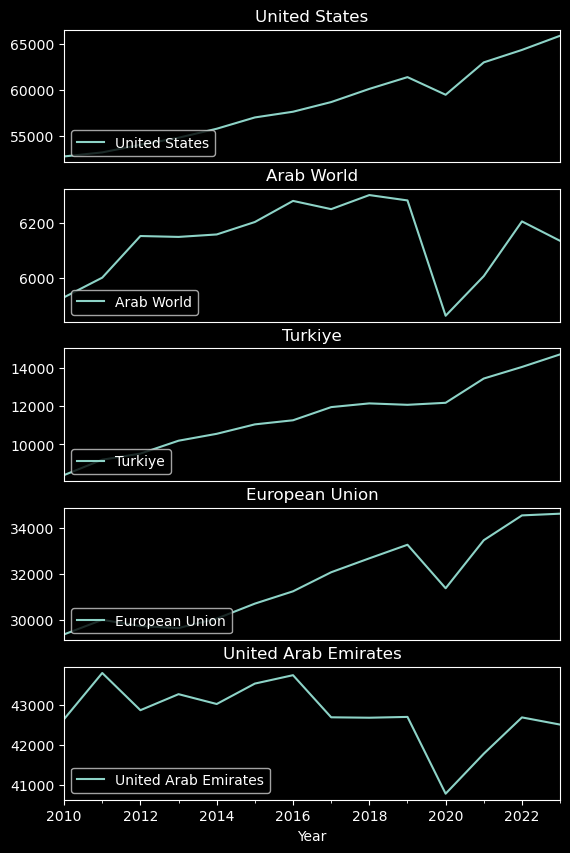

In [5]:
import matplotlib.pyplot as plt

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(len(pivot.columns), 1)
    fig.set_figheight(len(pivot.columns) * 2)
    for i, c in enumerate(pivot.columns):
        pivot[c].plot(ax=ax[i])
        ax[i].set_title(c)
        ax[i].legend(loc="lower left")
        if i < len(ax) - 1:
            ax[i].get_xaxis().set_visible(False)
    plt.show()

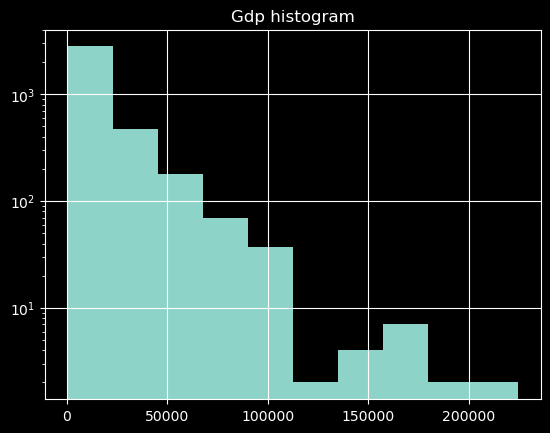

In [6]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots()
    ax.set_yscale("log")
    ax.set_title("Gdp histogram")
    df["Value"].hist(ax=ax)
    plt.show()

In [7]:
pd.DataFrame(df.groupby("Country")["Value"].mean()).sort_values(by="Value")

,Value
Country,
Burundi,274.323584
Central African Republic,416.165309
Somalia,437.047989
Madagascar,446.089776
"Congo, Dem. Rep.",457.951233
...,...
Switzerland,85075.045855
Luxembourg,106644.825075
Bermuda,107588.109216


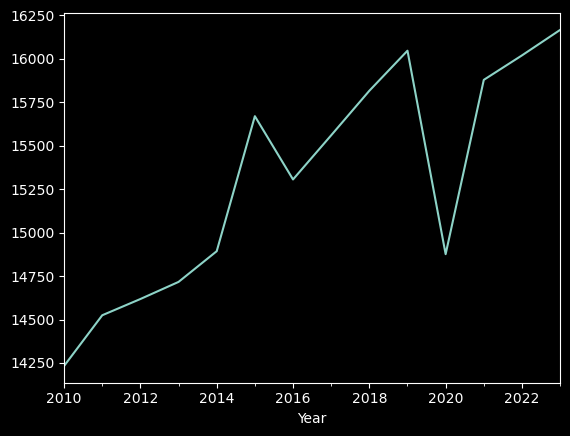

In [8]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots()
    df.groupby("Year")["Value"].mean().plot(ax=ax)
    plt.show()

In [9]:
def letters():
    df = pd.DataFrame(
        list(range(1, 26)),
        index=[chr(c + 64) for c in range(1, 26)],
        columns=["Values"],
    )
    df["Avg"] = df["Values"].cumsum() / np.arange(1, len(df) + 1)
    df["Sum"] = df["Values"].cumsum()
    display(df)


letters()

,Values,Avg,Sum
A,1,1.0,1
B,2,1.5,3
C,3,2.0,6
D,4,2.5,10
E,5,3.0,15
F,6,3.5,21
G,7,4.0,28
H,8,4.5,36
I,9,5.0,45
J,10,5.5,55


In [10]:
d2 = df.copy()
grouped = d2.groupby("Country")["Value"]
d2["Cumulative Average"] = grouped.cumsum() / (grouped.cumcount() + 1)
d2 = d2.set_index(["Country", "Year"])
d2 = d2.loc["United States"]
d2
# d2[d2["Country"] == "United States"]
# d2

,Value,Cumulative Average
Year,,
2023-01-01,65875.177881,65875.177881
2022-01-01,64342.117938,65108.647910
2021-01-01,62996.289384,64404.528401
2020-01-01,59493.145982,63176.682796
2019-01-01,61400.548154,62821.455868
2018-01-01,60127.210276,62372.414936
2017-01-01,58703.144078,61848.233385
2016-01-01,57658.670883,61324.538072
2015-01-01,57040.208214,60848.501421


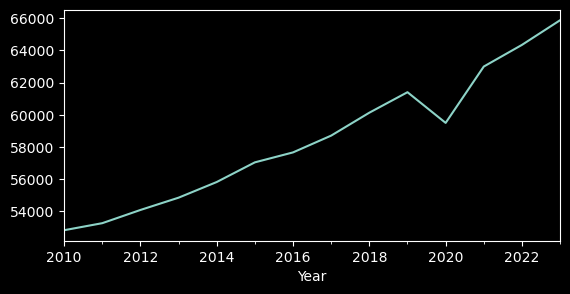

In [11]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots()
    fig.set_figheight(3)
    d2["Value"].plot(ax=ax)
    plt.show()

### Slope and intercept through sql

In [12]:
db.exec("view.country.slope-intercept")
cols = ["Country", "Slope", "Intercept", "Start Year", "End Year"]
trends = pd.DataFrame(
    db.select("view.country.slope-intercept"),
    columns=cols,
).set_index("Country")
trends = trends.astype(
    {
        "Start Year": int,
        "End Year": int,
    }
)

with pd.option_context("display.max_rows", 10):
    display(trends)

,Slope,Intercept,Start Year,End Year
Country,,,,
New Caledonia,NaN,NaN,2015,2015
Liechtenstein,NaN,NaN,2015,2015
Monaco,5192.788477,-1.029830e+07,2010,2023
Ireland,4336.372075,-8.675755e+06,2010,2023
Isle of Man,2012.150275,-3.970489e+06,2010,2021
...,...,...,...,...
Equatorial Guinea,-571.879314,1.161304e+06,2010,2023
Kuwait,-733.135080,1.507317e+06,2010,2023
Sint Maarten (Dutch part),-774.087103,1.596169e+06,2010,2023


In [13]:
# Indices that contain the word `united` regardless of casing
trends.loc[trends.index.str.contains(r"(?i)stan$", regex=True)]

,Slope,Intercept,Start Year,End Year
Country,,,,
Turkmenistan,285.997964,-570679.931846,2010,2023
Kazakhstan,170.810789,-334153.652307,2010,2023
Uzbekistan,117.265151,-233530.785055,2010,2023
Tajikistan,46.462278,-92645.194334,2010,2023
Pakistan,32.945991,-64986.292976,2010,2023
Afghanistan,-12.491152,25709.123794,2010,2023


In [14]:
dates = np.arange("2010", "2024", dtype="datetime64[Y]").astype(
    "datetime64[Y]"
)
dates

array(['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype='datetime64[Y]')

datetime64[ns]


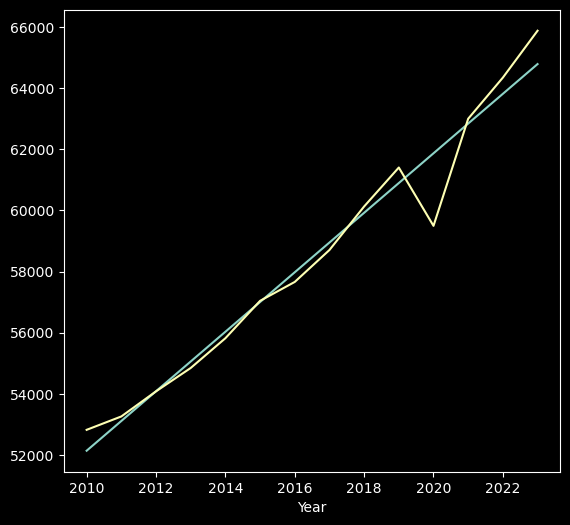

In [15]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots()
    fig.set_figheight(6)
    us_name = trends[
        trends.index.str.contains(r"(?i)United States", regex=True)
    ].index[0]
    trend = trends.loc[us_name].copy()
    values = pivot[us_name].copy()
    values.index = values.index.year.map(lambda v: np.int64(v))
    slope = cast(np.float64, trend["Slope"])
    intercept = cast(np.float64, trend["Intercept"])
    time = np.arange(
        trend["Start Year"], trend["End Year"] + 1, dtype=np.int64
    )
    pd.Series(slope * time + intercept, time).plot(ax=ax)
    values.plot(ax=ax)
    plt.show()

In [18]:
from typing import cast
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
fig.set_figwidth(8.3)
us_gdp = pivot.copy()
# us_gdp.columns = us_gdp.columns.droplevel(0)
us_gdp = us_gdp.rename(columns=lambda y: str(y).split("-")[0])

ax.plot(us_gdp["United States"], marker="o", color="green")

# years = np.array(us_gdp.index.map(lambda v: float(v)), dtype=np.float64)
years = np.array(us_gdp.index.map(lambda v: int(str(v).split("-")[0])))

slope = cast(np.float64, line.loc["United States", "Slope"])
intercept = cast(np.float64, line.loc["United States", "Intercept"])
print("Slope", slope)
print("Intercept", intercept)

ax.plot(years * slope + intercept)

ax.plot()

NameError: name 'line' is not defined

# Slope and intercept through pandas

In [ ]:
g = df.groupby("Country").get_group("United States")
# g.groups.keys()
g["Year"]

# Linear Regression

### Regression through Manual SQL

TODO The method used in this query is inefficient and needs to be worked on

In [ ]:
import sys
import pandas as pd
from scipy.stats import linregress
from IPython.display import display, HTML

trend = {"Raw": df.copy()}


def get_slope_intercept(group):
    if len(group) < 2 or group["Value"].var() == 0:
        return pd.Series({"Slope": np.nan, "Intercept": np.nan})
    year_numeric = group["Year"].dt.year - group["Year"].dt.year.min()
    slope, intercept, _, _, _ = linregress(year_numeric, group["Value"])
    return pd.Series({"Slope": slope, "Intercept": intercept})


trend["Pivoted"] = (
    trend["Raw"]
    .dropna()
    .groupby("Country")
    .apply(get_slope_intercept, include_groups=False)
    .reset_index()
)
trend["Pivoted"].head().to_csv(sys.stdout)

In [ ]:
import sys
import pandas as pd
from scipy.stats import linregress
from IPython.display import display, HTML
from bs4 import BeautifulSoup


# def get_slope_intercept(group):
#     if len(group) < 2 or group["Value"].var() == 0:
#         return pd.Series({"Slope": np.nan, "Intercept": np.nan})
#     year_numeric = group["Year"].dt.year - group["Year"].dt.year.min()
#     slope, intercept, _, _, _ = linregress(year_numeric, group["Value"])
#     return pd.Series({"Slope": slope, "Intercept": intercept})


# trend = {}
# trend["Pivoted"] = (
#     df.copy()
#     .dropna()
#     .groupby("Country")
#     .apply(get_slope_intercept, include_groups=False)
# )

trend["Melted"] = (
    trend["Pivoted"]
    .reset_index()
    .melt(
        id_vars=["Country"],
        value_vars=["Slope", "Intercept"],
        var_name="Type",
        value_name="Measurement",
    )
    .set_index(["Country", "Type"])
    .sort_index()
)

from IPython.display import display, HTML
from bs4 import BeautifulSoup


def dict_to_css(css: dict):
    return "; ".join([f"{k}: {v}" for k, v in css.items()])


soup = BeautifulSoup("", "html.parser")
wrapper = soup.new_tag(
    "div",
    attrs={
        "style": dict_to_css(
            {
                "display": "flex",
                "color": "gray",
                "gap": "1em",
            }
        )
    },
)
soup.append(wrapper)
for title, temp_df in trend.items():
    container = soup.new_tag("div")
    h1 = soup.new_tag("h1")
    h1.string = title
    container.append(h1)
    container.append(BeautifulSoup(temp_df.to_html(), "html.parser"))
    wrapper.append(container)

display(HTML(str(soup)))

### Regression through Postgres methods

In [ ]:
db.exec("view.country.stddev-samp")
df2 = pd.DataFrame(
    db.select("view.country.stddev-samp"), columns=["Country", "StdDevSamp"]
).set_index("Country")
df2

In [ ]:
df1 = df1.drop_duplicates()
df1

In [ ]:
df2.loc["Samoa"]